In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Input data
X = np.array([
    [1.0, 1.5], [1.2, 1.8], [0.8, 1.3], [1.1, 1.7], [0.9, 1.6],
    [4.5, 4.2], [4.7, 4.4], [4.4, 4.6], [4.6, 4.3], [4.5, 4.5],
    [7.2, 8.0], [7.3, 7.9], [7.1, 8.1], [7.4, 8.2], [7.3, 8.3],
    [9.0, 10.0], [9.1, 10.1], [9.2, 10.2], [9.3, 10.3], [9.4, 10.4]
])

In [ ]:
class KMeansScratch:
    def __init__(self, n_clusters, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        np.random.seed(random_state)

    def initialize_centroids(self, X):
        """Randomly initialize centroids from the dataset."""
        random_indices = np.random.permutation(X.shape[0])[:self.n_clusters]
        return X[random_indices]

    def assign_clusters(self, X, centroids):
        """Assign each data point to the closest centroid."""
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        return np.argmin(distances, axis=1)

    def update_centroids(self, X, labels):
        """Update centroids as the mean of points in each cluster."""
        centroids = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            centroids[k] = cluster_points.mean(axis=0) if len(cluster_points) > 0 else centroids[k]
        return centroids

    def fit(self, X):
        """Fit the K-Means model to the data."""
        self.centroids = self.initialize_centroids(X)

        for _ in range(self.max_iters):
            self.labels = self.assign_clusters(X, self.centroids)
            new_centroids = self.update_centroids(X, self.labels)
            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids

    def predict(self, X):
        """Predict the closest cluster for each data point."""
        return self.assign_clusters(X, self.centroids)


In [ ]:
# Applying K-Means from scratch
kmeans = KMeansScratch(n_clusters=4, max_iters=100)
kmeans.fit(X)
labels = kmeans.predict(X)

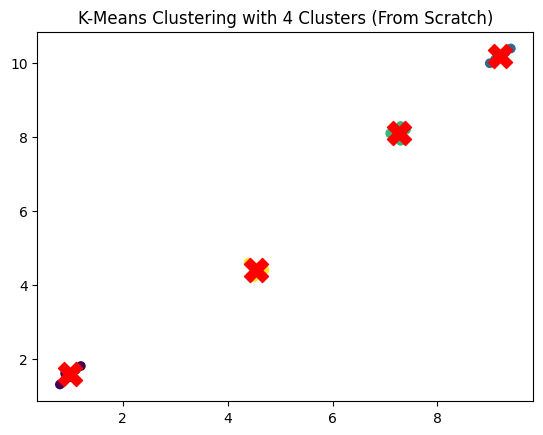

In [ ]:
# Plotting the clusters
x_coords = X[:, 0]
y_coords = X[:, 1]
plt.scatter(x_coords, y_coords, c=labels, cmap='viridis')
plt.scatter(
    kmeans.centroids[:, 0],
    kmeans.centroids[:, 1],
    s=300, c='red', marker='X'
)
plt.title("K-Means Clustering with 4 Clusters (From Scratch)")
plt.show()